In [26]:
#%matplotlib qt5

In [27]:
import time
import numpy as np
import pykep as pk
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

from utils import *
from cartesian_dynamics import *
from ks_dynamics import *

In [ ]:
# Define orbit parameters from the table
orbits = {
    'A': {'eccentricity': 0.1, 'semi_major_axis': 7000},  # km
    'B': {'eccentricity': 0.9, 'semi_major_axis': 70000}, # km  
    'C': {'eccentricity': 2.0, 'semi_major_axis': -7000},  # km (hyperbolic orbit)
}

GM_earth = 3.986e5 # km^3/s^2

In [ ]:
orbit_to_use = 'B'
a = orbits[orbit_to_use]['semi_major_axis']  # km
e = orbits[orbit_to_use]['eccentricity']

# === TIME SETTINGS ===
dt = 10  # time step [s]
n_orbits = 5
T = 2 * np.pi * np.sqrt(np.abs(a) ** 3 / GM_earth)  # orbital period [s]
t_final = n_orbits * T
N = int(t_final / dt)
print(f"Orbital period: {T/3600:.2f} hours | Total simulation time: {t_final/3600:.2f} hours | Number of time steps: {N}")

# === INITIAL CONDITIONS ===
# Initial conditions at perigee (3D) - starting at periapsis (M=0)
# Orbital elements: [a, e, i, RAAN, omega, M]
# At periapsis: M = 0, i = 0, RAAN = 0, omega = 0
a_abs = abs(a) if a < 0 else a
oe_vec_0 = [a_abs, e, 0.0, 0.0, 0.0, 0.0]  # [a, e, i, RAAN, omega, M] in km
r0_vec, v0_vec = pk.par2ic(oe_vec_0, GM_earth)

# Convert tuples to numpy arrays (already in km and km/s)
r0_vec = np.array(r0_vec)  # km
v0_vec = np.array(v0_vec)  # km/s

# Initial state in Cartesian and KS coordinates
state0 = np.concatenate([r0_vec, v0_vec])
ks_state0 = cartesian_coordinates2ks_state(state0[:3])
ks_state_dot0 = cartesian_velocity2ks_state_dot(state0[3:], ks_state0)
ks_augmented_state0 = np.concatenate([ks_state0, ks_state_dot0])

Orbital period: 51.20 hours | Total simulation time: 255.99 hours | Number of time steps: 92156


In [30]:
# Cartesian solutions (3D)
t_vals = np.linspace(0, N * dt, N + 1)

# Integrate in a single call for better accuracy (instead of step-by-step)
start_time_cartesian_rk4 = time.time()
solution_rk4 = solve_ivp(lambda t, y: two_body_ode(t, y, GM_earth), [0, N * dt], state0, method='RK45', t_eval=t_vals, rtol=1e-12, atol=1e-12)
states_cartesian_rk4 = solution_rk4.y.T  # Transpose to get (N+1, 6) shape
elapsed_time_cartesian_rk4 = time.time() - start_time_cartesian_rk4
x_cartesian_rk4, y_cartesian_rk4, z_cartesian_rk4, theta_cartesian_rk4, r_vec_cartesian_rk4, r_vec_norm_cartesian_rk4 = r_vecs2several_quantities(states_cartesian_rk4[:, :3])

x_cartesian_analytical = np.zeros(N + 1)
y_cartesian_analytical = np.zeros(N + 1)
z_cartesian_analytical = np.zeros(N + 1)
theta_cartesian_analytical = np.zeros(N + 1)
r_vec_cartesian_analytical = np.zeros((N + 1, 3))
r_vec_norm_cartesian_analytical = np.zeros(N + 1)
for i in range(N + 1):
    x_cartesian_analytical[i], y_cartesian_analytical[i], z_cartesian_analytical[i], r_vec_cartesian_analytical[i], r_vec_norm_cartesian_analytical[i] = analytical_solution(t_vals[i], a, e, GM_earth)
    theta_cartesian_analytical[i] = np.arctan2(y_cartesian_analytical[i], x_cartesian_analytical[i])

In [31]:
# KS solution (3D)
ds = dt / a
s_vals = np.linspace(0, N * ds, N + 1)

# Integrate in a single call for better accuracy (instead of step-by-step)
start_time_ks_rk4 = time.time()
solution_ks_rk4 = solve_ivp(lambda t, y: ks_ode_system(t, y, GM_earth), [0, N * ds], ks_augmented_state0, method='RK45', t_eval=s_vals, rtol=1e-12, atol=1e-12)
ks_augmented_states_ks_rk4 = solution_ks_rk4.y.T  # Transpose to get (N+1, 8) shape
# Convert KS states to Cartesian positions
r_vec_ks_rk4 = np.array([ks_state2cartesian_coordinates(ks_augmented_states_ks_rk4[i, :4]) for i in range(N + 1)])
elapsed_time_ks_rk4 = time.time() - start_time_ks_rk4
x_ks_rk4, y_ks_rk4, z_ks_rk4, theta_ks_rk4, r_vec_ks_rk4, r_vec_norm_ks_rk4 = r_vecs2several_quantities(r_vec_ks_rk4)

x_ks_rk4_analytical = np.zeros(N + 1)
y_ks_rk4_analytical = np.zeros(N + 1)
z_ks_rk4_analytical = np.zeros(N + 1)
theta_ks_rk4_analytical = np.zeros(N + 1)
r_vec_ks_rk4_analytical = np.zeros((N + 1, 3))
r_vec_norm_ks_rk4_analytical = np.zeros(N + 1)
t_vals_ks_rk4 = np.zeros_like(s_vals)
for i in range(N + 1):
    if i > 0:
        t_vals_ks_rk4[i] = t_vals_ks_rk4[i - 1] + (r_vec_norm_ks_rk4[i] + r_vec_norm_ks_rk4[i - 1]) / 2 * ds
    x_ks_rk4_analytical[i], y_ks_rk4_analytical[i], z_ks_rk4_analytical[i], r_vec_ks_rk4_analytical[i], r_vec_norm_ks_rk4_analytical[i] = analytical_solution(t_vals_ks_rk4[i], a, e, GM_earth)
    theta_ks_rk4_analytical[i] = np.arctan2(y_ks_rk4_analytical[i], x_ks_rk4_analytical[i])

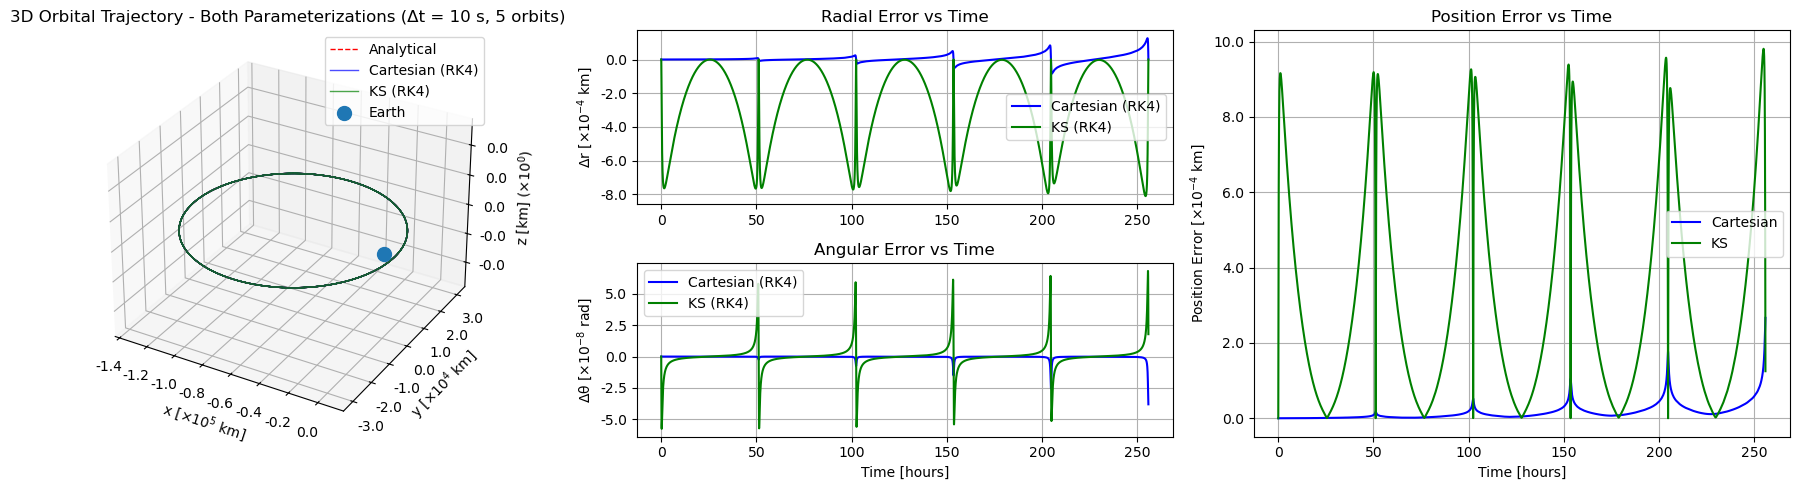

In [32]:
fig = plt.figure(figsize=(18, 5))
gs = fig.add_gridspec(2, 3)  # 2 rows, 3 columns total

radial_error_cartesian = r_vec_norm_cartesian_rk4 - r_vec_norm_cartesian_analytical
radial_error_ks = r_vec_norm_ks_rk4 - r_vec_norm_ks_rk4_analytical
angular_error_cartesian = np.mod(theta_cartesian_rk4 - theta_cartesian_analytical + np.pi, 2 * np.pi) - np.pi
angular_error_ks = np.mod(theta_ks_rk4 - theta_ks_rk4_analytical + np.pi, 2 * np.pi) - np.pi
position_error_cartesian = np.linalg.norm(r_vec_cartesian_rk4 - r_vec_cartesian_analytical, axis=1)
position_error_ks = np.linalg.norm(r_vec_ks_rk4 - r_vec_ks_rk4_analytical, axis=1)

# --- Plot 1: 3D Trajectory comparison (spans both rows in column 0) - Both parameterizations
ax1 = fig.add_subplot(gs[:, 0], projection='3d')
ax1.plot(x_cartesian_analytical, y_cartesian_analytical, z_cartesian_analytical, 
         '--', label='Analytical', color='red', linewidth=1)
ax1.plot(x_cartesian_rk4, y_cartesian_rk4, z_cartesian_rk4, 
         label='Cartesian (RK4)', color='blue', linewidth=1, alpha=0.7)
ax1.plot(x_ks_rk4, y_ks_rk4, z_ks_rk4, 
         label='KS (RK4)', color='green', linewidth=1, alpha=0.7)
ax1.scatter(0, 0, 0, 'ro', label='Earth', s=100)
ax1.set_xlabel('x [km]')
ax1.set_ylabel('y [km]')
ax1.set_zlabel('z [km]')
ax1.set_title(f'3D Orbital Trajectory - Both Parameterizations (Δt = {dt} s, {n_orbits} orbits)')
ax1.legend()

# --- Plot 2a: Δr vs Time (top-right) - Both parameterizations
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(t_vals / 3600, radial_error_cartesian, label='Cartesian (RK4)', color='blue', linewidth=1.5)
ax2.plot(t_vals_ks_rk4 / 3600, radial_error_ks, label='KS (RK4)', color='green', linewidth=1.5)
ax2.set_ylabel('Δr [km]')
ax2.set_title('Radial Error vs Time')
ax2.legend()
ax2.grid(True)

# --- Plot 2b: Δθ vs Time (bottom-right) - Both parameterizations
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(t_vals / 3600, angular_error_cartesian, label='Cartesian (RK4)', color='blue', linewidth=1.5)
ax3.plot(t_vals_ks_rk4 / 3600, angular_error_ks, label='KS (RK4)', color='green', linewidth=1.5)
ax3.set_xlabel('Time [hours]')
ax3.set_ylabel('Δθ [rad]')
ax3.set_title('Angular Error vs Time')
ax3.legend()
ax3.grid(True)

# --- Plot 3: Position error vs Time (spans both rows in column 2) - Both parameterizations
ax4 = fig.add_subplot(gs[:, 2])
ax4.plot(t_vals / 3600, position_error_cartesian, label='Cartesian', color='blue', linewidth=1.5)
ax4.plot(t_vals_ks_rk4 / 3600, position_error_ks, label='KS', color='green', linewidth=1.5)
ax4.set_xlabel('Time [hours]')
ax4.set_ylabel('Position Error [km]')
ax4.set_title('Position Error vs Time')
ax4.legend()
ax4.grid(True)

# Apply scientific tick formatting
apply_scientific_tick_labels(ax1, 'x', [x_cartesian_analytical, x_cartesian_rk4, x_ks_rk4])
apply_scientific_tick_labels(ax1, 'y', [y_cartesian_analytical, y_cartesian_rk4, y_ks_rk4])
apply_scientific_tick_labels(ax1, 'z', [z_cartesian_analytical, z_cartesian_rk4, z_ks_rk4])
apply_scientific_tick_labels(ax2, 'y', [radial_error_cartesian, radial_error_ks])
apply_scientific_tick_labels(ax3, 'y', [angular_error_cartesian, angular_error_ks])
apply_scientific_tick_labels(ax4, 'y', [position_error_cartesian, position_error_ks])

# --- Final layout
plt.tight_layout()
plt.show()

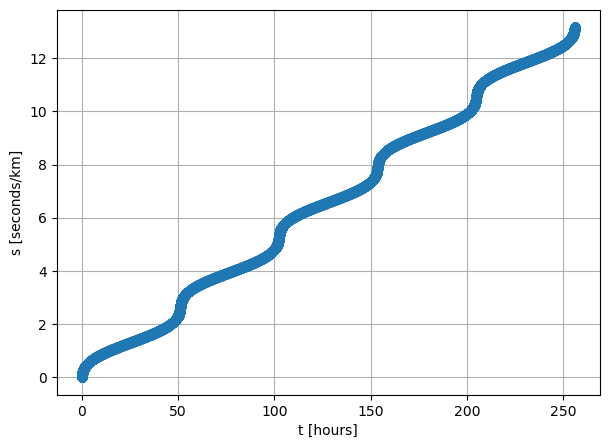

In [33]:
plt.figure(figsize=(7, 5))
plt.plot(t_vals_ks_rk4 / 3600, s_vals, marker='o', linestyle='-')
plt.xlabel('t [hours]')
plt.ylabel('s [seconds/km]')
plt.grid(True)
plt.show()